In [5]:
pip install imbalanced-learn

   ---------------------------------------- 0.0/258.0 kB ? eta -:--:--
   - -------------------------------------- 10.2/258.0 kB ? eta -:--:--
   ------------ -------------------------- 81.9/258.0 kB 907.3 kB/s eta 0:00:01
   ---------------------------------------  256.0/258.0 kB 2.0 MB/s eta 0:00:01
   ---------------------------------------- 258.0/258.0 kB 2.0 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [7]:
import numpy as np
import pandas as pd
from sklearn.datasets import make_classification
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from imblearn.over_sampling import RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler
from imblearn.ensemble import BalancedBaggingClassifier
# Generowanie przykładowych niezbalansowanych danych


In [ ]:
cosmos = pd.read_csv("neo.csv")
X, y = make_classification(n_classes=2, class_sep=2, weights=[0.1, 0.9],
                           n_informative=3, n_redundant=1, flip_y=0,
                           n_features=20, n_clusters_per_class=1,
                           n_samples=1000, random_state=10)
# Podział danych na zestawy treningowe i testowe
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
# Tworzenie ensemble modelu z zbalansowanymi próbami
ensemble_model = BalancedBaggingClassifier(
    base_estimator=RandomForestClassifier(),
    sampling_strategy='auto',  # Można ustawić na 'minority' dla oversamplingu, 'majority' dla undersamplingu
    replacement=False,
    random_state=42
)
# Trenowanie ensemble modelu
ensemble_model.fit(X_train, y_train)
# Predykcja na zestawie testowym
y_pred = ensemble_model.predict(X_test)
# Ocena modelu
print(classification_report(y_test, y_pred))



In [175]:
cosmos.head()


,est_diameter_min,est_diameter_max,relative_velocity,miss_distance,absolute_magnitude,hazardous
0,1.198271,2.679415,13569.249224,5.483974e+07,16.73,0
1,0.265800,0.594347,73588.726663,6.143813e+07,20.00,1
2,0.722030,1.614507,114258.692129,4.979872e+07,17.83,0
3,0.096506,0.215794,24764.303138,2.543497e+07,22.20,0
4,0.255009,0.570217,42737.733765,4.627557e+07,20.09,1


In [176]:
cosmos = cosmos.drop(['id','name','orbiting_body','sentry_object'], axis=1) #porzucenie kolumn
cosmos

KeyError: "['id', 'name', 'orbiting_body', 'sentry_object'] not found in axis"

In [177]:
cosmos['hazardous'] = cosmos['hazardous'].astype(int)

In [178]:
X = cosmos.drop(['hazardous'], axis=1) #stworzenie grup x,y 
y = cosmos['hazardous']


In [179]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [188]:
reg = xgb.XGBClassifier(learning_rate = 0.5, reg_lambda=1, gamma = 0.01,
                       objective='reg:squarederror',
                       n_estimators=100, max_depth=3)

reg.fit(X_train,y_train)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=0.01, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.5, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=3, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=None,
              num_parallel_tree=None, objective='reg:squarederror', ...)

In [189]:
print("Accuracy on training set: {:.2f}".format(reg.score(X_train, y_train)))
print("Accuracy on test set: {:.2f}".format(reg.score(X_test, y_test)))

Accuracy on training set: 0.92
Accuracy on test set: 0.92


In [190]:
pred_test = reg.predict(X_test) #model.predict zwraca przynależność do klasy


In [191]:
params={
    'learning_rate':[0.01, 0.5, 3],
    'reg_lambda':[0.1,1,5],
    'gamma':[0.00001, 0.01, 0.1],
    'n_estimators':[10,50,100],
    'max_depth':[3,7,10]
}


In [192]:
grid_search=GridSearchCV(reg, params )

In [193]:
grid_search.fit(X_train, y_train)

KeyboardInterrupt: 

In [186]:
print(grid_search.best_params_)

{'gamma': 0.01, 'learning_rate': 0.5, 'max_depth': 3, 'n_estimators': 100, 'reg_lambda': 1}


In [198]:
pred_train = reg.predict(X_train) #model.predict zwraca przynależność do klasy

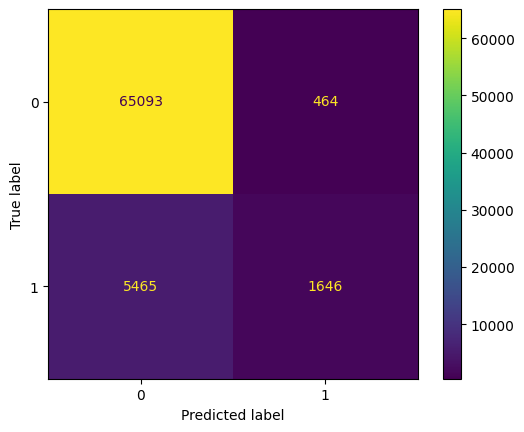

In [200]:
ConfusionMatrixDisplay.from_predictions(y_train, pred_train)

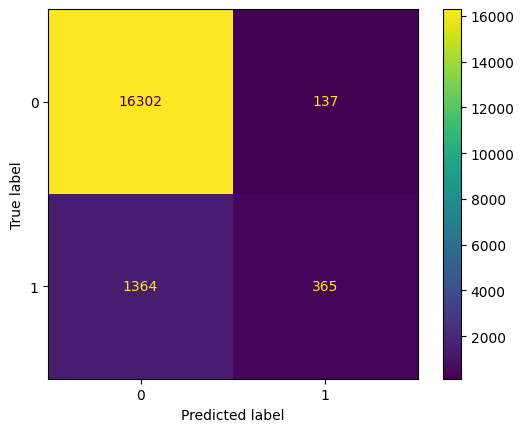

In [195]:
ConfusionMatrixDisplay.from_predictions(y_test,pred_test)

In [197]:

print(classification_report(y_test, pred_test))

              precision    recall  f1-score   support

           0       0.92      0.99      0.96     16439
           1       0.73      0.21      0.33      1729

    accuracy                           0.92     18168
   macro avg       0.82      0.60      0.64     18168
weighted avg       0.90      0.92      0.90     18168

